# 02.4 — Gradient Descent

**Phase:** 02 — Mathematics for ML

**Difficulty:** Intermediate

**Priority:** Core — this is how every model learns

**Status:** VERIFIED

---

## 1. What Are We Solving?

You know what derivatives and gradients are (Unit 02.3). Now: **how do you actually use them to train a model?**

Gradient descent is the answer. It's the algorithm that iteratively adjusts model parameters to minimize the loss function. Every model you'll ever train — linear regression, neural networks, transformers — uses some form of gradient descent.

## 2. Why Does This Matter?

Understanding gradient descent lets you:
- **Debug training**: why is my loss not decreasing? (learning rate too high/low)
- **Choose optimizers**: when to use SGD vs Adam vs AdaGrad
- **Tune hyperparameters**: learning rate, batch size, momentum
- **Understand convergence**: why some problems are harder to train than others

Without this knowledge, you're guessing. With it, you're engineering.

## 3. Prerequisites

- Unit 02.1 (Vectors & Matrices)
- Unit 02.2 (Matrix Operations)
- Unit 02.3 (Derivatives & Gradients) — you must understand what a gradient is

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- [ ] Explain the gradient descent update rule and why it works
- [ ] Implement gradient descent from scratch in Python
- [ ] Explain the role of the learning rate and diagnose too-high/too-low values
- [ ] Visualize convergence and recognize divergence
- [ ] Compare batch, stochastic, and mini-batch gradient descent
- [ ] Apply gradient descent to a simple linear regression problem

## 5. Mental Model

Imagine you're blindfolded on a hilly landscape and want to reach the lowest point. You can't see, but you can feel the slope under your feet.

What do you do? **Feel the slope, then take a step downhill.**

```
Gradient descent:
1. Compute the gradient (which way is steepest uphill)
2. Take a step in the OPPOSITE direction (downhill)
3. Repeat until the slope is flat (you're at a minimum)

Update rule:
  θ_new = θ_old - α × ∇L(θ)
          ↑       ↑     ↑
        params  step   gradient
                size   (direction)
```

The **learning rate** α controls how big each step is. Too big → you overshoot. Too small → you take forever.

## 6. Core Concepts: The Update Rule

The gradient descent algorithm is remarkably simple:

```
θ_new = θ_old - α × ∇L(θ)

Where:
  θ     = model parameters (weights)
  α     = learning rate (step size, e.g., 0.01)
  ∇L(θ) = gradient of the loss w.r.t. parameters
```

**Why subtract?** The gradient points uphill (direction of steepest increase). We want to go downhill (decrease loss), so we move in the opposite direction.

**Why does it work?** At each step, the gradient tells you the direction of steepest increase. Moving opposite guarantees you're going downhill (at least locally). With a small enough learning rate, you'll converge to a minimum.

Let's start with the simplest case: minimizing `f(x) = x²`, whose minimum is at `x = 0` and whose derivative is `2x`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Minimize f(x) = x^2, whose derivative is f'(x) = 2x
def f(x):
    return x**2

def df(x):
    return 2 * x

# Gradient descent
def gradient_descent_1d(df, x0, learning_rate=0.1, n_iter=50):
    x = x0
    history = []
    for i in range(n_iter):
        history.append(x)
        x = x - learning_rate * df(x)
    return x, history

x_final, history = gradient_descent_1d(df, x0=5.0, learning_rate=0.1, n_iter=50)
print(f"Starting at x=5.0")
print(f"Final x: {x_final:.6f} (true minimum at 0)")
print(f"Final f(x): {f(x_final):.6f}")
print(f"First 5 steps: {[round(h, 4) for h in history[:5]]}")


Starting at x=5.0
Final x: 0.000071 (true minimum at 0)
Final f(x): 0.000000
First 5 steps: [5.0, 4.0, 3.2, 2.56, 2.048]


## 7. Experiment: Visualizing Convergence

Let's watch gradient descent minimize `f(x) = x²` step by step, starting from `x = 5`.

```
Start: x = 5,  f(x) = 25
Step 1: x = 5 - 0.1×10 = 4.0,  f(x) = 16
Step 2: x = 4 - 0.1×8  = 3.2,  f(x) = 10.24
...
Step 50: x ≈ 0.0001,   f(x) ≈ 0.0000
```

Each step reduces the loss. The steps get smaller as we approach the minimum (because the gradient gets smaller).

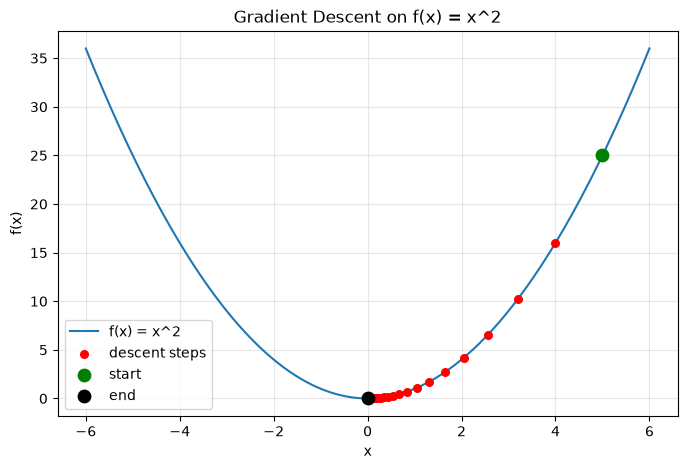

In [2]:
# Visualize the descent path
x_vals = np.linspace(-6, 6, 200)
y_vals = f(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label="f(x) = x^2")
plt.scatter(history, [f(h) for h in history], color="red", s=30, zorder=5, label="descent steps")
plt.scatter([history[0]], [f(history[0])], color="green", s=80, zorder=6, label="start")
plt.scatter([x_final], [f(x_final)], color="black", s=80, zorder=6, label="end")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent on f(x) = x^2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. The Learning Rate

The **learning rate** (α) is the single most important hyperparameter in training. It controls how big each step is.

```
Too small (α = 0.001):         Too large (α = 0.5):          Just right (α = 0.1):
  Step 1: 5.0 → 4.99            Step 1: 5.0 → -5.0            Step 1: 5.0 → 4.0
  Step 2: 4.99 → 4.98           Step 2: -5.0 → 5.0            Step 2: 4.0 → 3.2
  Step 3: 4.98 → 4.97           Step 3: 5.0 → -5.0            Step 3: 3.2 → 2.56
  ...oscillates forever...       ...diverges!...               ...converges!
```

**Rules of thumb:**
- Start with α = 0.01 or 0.001
- If loss decreases but slowly → increase α
- If loss oscillates or increases → decrease α
- Use learning rate scheduling: start large, decay over time

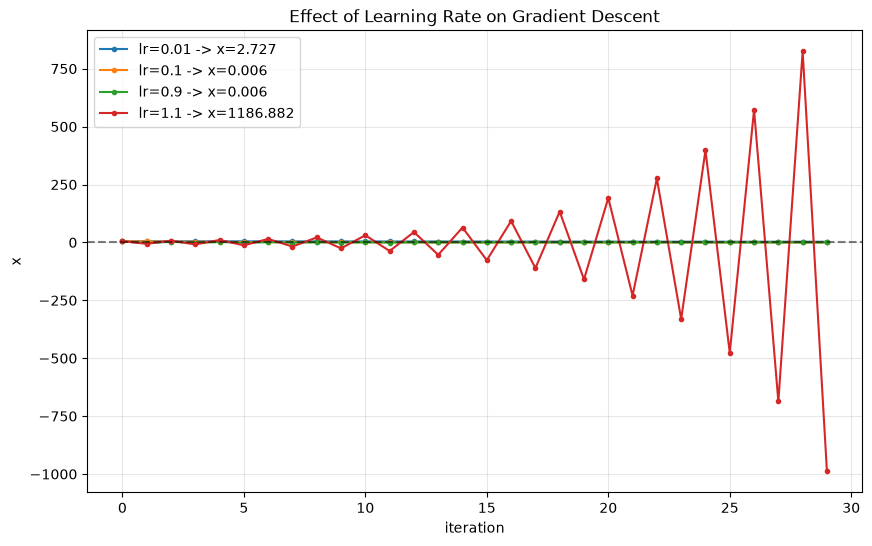

Note: lr=1.1 diverges (x grows without bound); lr=0.01 is slow; lr=0.1 is a good balance.


In [3]:
# Effect of learning rate on convergence
def run(lr, n_iter=30):
    x = 5.0
    hist = []
    for _ in range(n_iter):
        hist.append(x)
        x = x - lr * df(x)
    return x, hist

lrs = [0.01, 0.1, 0.9, 1.1]
plt.figure(figsize=(10, 6))
for lr in lrs:
    x_f, hist = run(lr)
    plt.plot(range(len(hist)), hist, marker="o", markersize=3, label=f"lr={lr} -> x={x_f:.3f}")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.xlabel("iteration")
plt.ylabel("x")
plt.title("Effect of Learning Rate on Gradient Descent")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Note: lr=1.1 diverges (x grows without bound); lr=0.01 is slow; lr=0.1 is a good balance.")


## 9. Core Concepts: Gradient Descent for Linear Regression

Now let's apply gradient descent to a real task: fitting a line `y = w*x + b` to data by minimizing MSE.

```
Loss function:  L = (1/n) Σ (y_pred - y)²
Model:          y_pred = w * x + b

Gradients:
  ∂L/∂w = (2/n) Σ (y_pred - y) × x    ← how much w affects the loss
  ∂L/∂b = (2/n) Σ (y_pred - y)         ← how much b affects the loss

Update:
  w = w - α × ∂L/∂w
  b = b - α × ∂L/∂b
```

This is exactly what `sklearn.linear_model.LinearRegression` does internally (but faster, using the normal equation).

In [4]:
# Generate synthetic data: y = 2x + 1 + noise
np.random.seed(42)
n = 100
X = np.random.uniform(-3, 3, n)
y_true = 2 * X + 1 + np.random.randn(n) * 0.5

def mse(w, b):
    y_pred = w * X + b
    return np.mean((y_pred - y_true) ** 2)

def gradients(w, b):
    y_pred = w * X + b
    dw = (2 / n) * np.sum((y_pred - y_true) * X)
    db = (2 / n) * np.sum(y_pred - y_true)
    return dw, db

# Gradient descent
w, b = 0.0, 0.0
lr = 0.05
loss_history = []
for i in range(200):
    dw, db = gradients(w, b)
    w = w - lr * dw
    b = b - lr * db
    loss_history.append(mse(w, b))

print(f"Learned w: {w:.4f} (true 2.0)")
print(f"Learned b: {b:.4f} (true 1.0)")
print(f"Final MSE: {loss_history[-1]:.4f}")


Learned w: 1.9617 (true 2.0)
Learned b: 0.9926 (true 1.0)
Final MSE: 0.2016


## 10. Experiment: Visualizing the Loss Curve

A key diagnostic: the loss should **decrease monotonically** (for convex problems like linear regression).

```
Good:  loss decreases steadily → model is learning
Bad:   loss oscillates → learning rate too high
Bad:   loss plateaus → learning rate too low or stuck in local minimum
Bad:   loss increases → divergence (learning rate way too high)
```

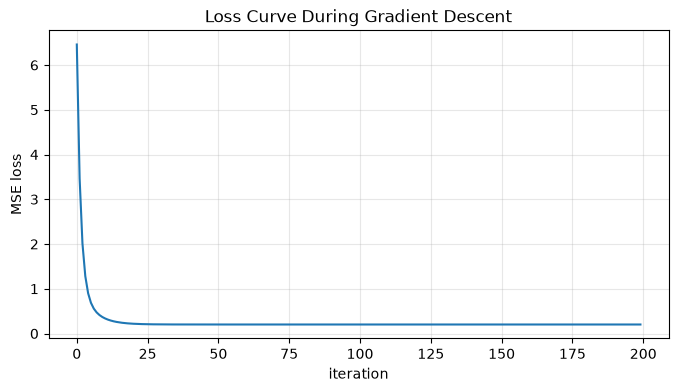

Loss went from 6.4585 to 0.2016


In [5]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("iteration")
plt.ylabel("MSE loss")
plt.title("Loss Curve During Gradient Descent")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Loss went from {loss_history[0]:.4f} to {loss_history[-1]:.4f}")


## 11. Batch vs Stochastic vs Mini-Batch

How much data do you use per gradient update? This is the key design choice:

```
Batch GD:        use ALL N samples → exact gradient, slow per step
Stochastic GD:   use 1 sample      → noisy gradient, fast per step
Mini-batch GD:   use B samples     → good compromise, what everyone uses
```

**Why mini-batch wins:**
- GPUs process batches efficiently (parallelism)
- Some noise in the gradient helps escape local minima
- Typical batch sizes: 32, 64, 128, 256

**One epoch** = one pass through the entire dataset. With batch size B, one epoch has N/B updates.

Mini-batch: w=2.0204, b=0.9856, final MSE=0.2128


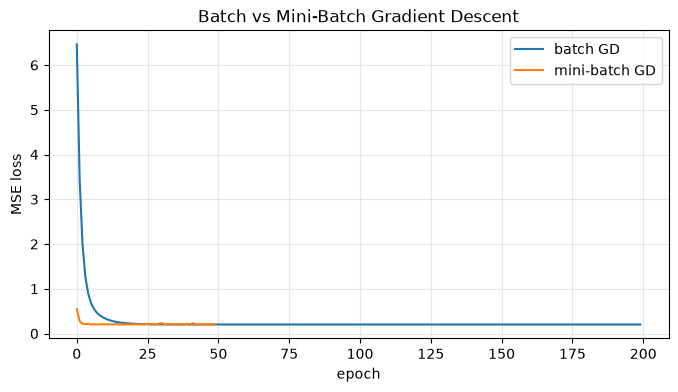

In [6]:
# Mini-batch gradient descent
def mini_batch_gd(X, y_true, lr=0.05, n_epochs=50, batch_size=16):
    w, b = 0.0, 0.0
    n = len(X)
    loss_history = []
    for epoch in range(n_epochs):
        # Shuffle data each epoch
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y_true[idx]
        for start in range(0, n, batch_size):
            end = start + batch_size
            Xb, yb = X_s[start:end], y_s[start:end]
            y_pred = w * Xb + b
            dw = (2 / len(Xb)) * np.sum((y_pred - yb) * Xb)
            db = (2 / len(Xb)) * np.sum(y_pred - yb)
            w = w - lr * dw
            b = b - lr * db
        loss_history.append(mse(w, b))
    return w, b, loss_history

np.random.seed(7)
w_mb, b_mb, loss_mb = mini_batch_gd(X, y_true)
print(f"Mini-batch: w={w_mb:.4f}, b={b_mb:.4f}, final MSE={loss_mb[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(loss_history, label="batch GD")
plt.plot(loss_mb, label="mini-batch GD")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Batch vs Mini-Batch Gradient Descent")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 12. Common Mistakes: Divergence

The most common training failure: **the learning rate is too large**.

```
Normal:  θ = θ - 0.1 × ∇L  →  loss decreases
Too big: θ = θ - 5.0 × ∇L  →  loss explodes!

What happens:
  Step 1: θ = 5.0 → -5.0   (overshot the minimum at 0)
  Step 2: θ = -5.0 → 15.0  (even further!)
  Step 3: θ = 15.0 → -25.0 (diverging to infinity)
```

**Diagnosis:** If the loss suddenly spikes or goes to NaN, try reducing the learning rate by 10x.

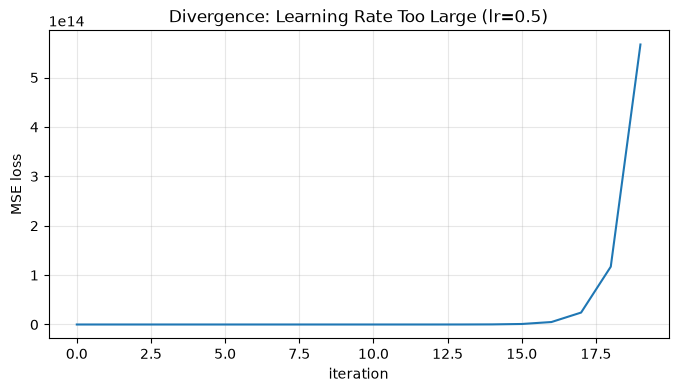

Loss exploded to 5.67e+14 - the model diverged.
Fix: reduce the learning rate.


In [7]:
# Divergence with too-large learning rate
w, b = 0.0, 0.0
lr_bad = 0.5
bad_loss = []
for i in range(20):
    dw, db = gradients(w, b)
    w = w - lr_bad * dw
    b = b - lr_bad * db
    bad_loss.append(mse(w, b))

plt.figure(figsize=(8, 4))
plt.plot(bad_loss)
plt.xlabel("iteration")
plt.ylabel("MSE loss")
plt.title("Divergence: Learning Rate Too Large (lr=0.5)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Loss exploded to {bad_loss[-1]:.2e} - the model diverged.")
print("Fix: reduce the learning rate.")


## 13. Hands-On Practice

**Level 1 — Recall:** What is the gradient descent update rule? What does the learning rate control?

**Level 2 — Apply:** Implement gradient descent to minimize `f(x) = (x-3)²`. Start from x=0, use α=0.1. Verify convergence to x=3.

**Level 3 — Compute:** Fit `y = 2x + 1 + noise` using gradient descent. Plot the loss curve and verify w≈2, b≈1.

**Level 4 — Debug:** Your gradient descent is diverging. The loss goes to NaN after 10 iterations. What are 3 things to check?

**Level 5 — Create:** Implement mini-batch gradient descent with learning rate scheduling (α decreases over time). Compare convergence with batch GD.

## 14. Real-World ML Application

In practice, you never write gradient descent from scratch. But understanding it helps you use the tools effectively:

```python
# PyTorch training loop
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(100):
    for batch_X, batch_y in dataloader:
        loss = compute_loss(model(batch_X), batch_y)
        loss.backward()              # compute gradients
        optimizer.step()             # update weights
        optimizer.zero_grad()        # reset gradients
```

**Optimizers beyond vanilla GD:**
- **SGD with momentum**: smoother convergence
- **Adam**: adaptive learning rate per parameter (the default choice)
- **Learning rate scheduling**: decay α over time for better convergence

## 15. Debugging: Common Errors

**Loss is NaN or exploding:**
```python
# Cause: learning rate too large
# Fix: reduce lr by 10x, or normalize features
```

**Loss plateaus:**
```python
# Cause: learning rate too small, or stuck in local minimum
# Fix: increase lr, or use momentum/Adam
```

**Slow convergence:**
```python
# Cause: features on very different scales
# Fix: standardize features (zero mean, unit variance)
```

## 16. Knowledge Check

Answer without running code:

1. What is the gradient descent update rule? Why do we subtract the gradient?
2. What happens if the learning rate is too large? Too small?
3. What is the difference between batch, stochastic, and mini-batch GD?
4. Why do we need feature scaling for gradient descent to work well?
5. When would you use the normal equation instead of gradient descent?

## 17. Exit Criteria

You're ready to move on when you can:
- [ ] Implement gradient descent from scratch for a simple function
- [ ] Explain the role of learning rate and diagnose common issues
- [ ] Compare batch, stochastic, and mini-batch gradient descent
- [ ] Apply gradient descent to fit a linear regression model
- [ ] Know when to use normal equation vs gradient descent
- [ ] Recognize the signs of divergence and know how to fix it

## 18. Next Step

**→ 02.5 Probability**: Now that you know how models learn, learn the probability theory behind loss functions, Bayesian inference, and generative models.

In [8]:
# Challenge: Stochastic Gradient Descent (one sample per update)
np.random.seed(11)
w, b = 0.0, 0.0
n_epochs = 100
for epoch in range(n_epochs):
    # Decay the learning rate for stable convergence
    lr = 0.05 / (1 + 0.01 * epoch)
    idx = np.random.permutation(n)
    for i in idx:
        xi, yi = X[i], y_true[i]
        y_pred = w * xi + b
        dw = 2 * (y_pred - yi) * xi
        db = 2 * (y_pred - yi)
        w = w - lr * dw
        b = b - lr * db

print(f"SGD learned w: {w:.4f} (true 2.0)")
print(f"SGD learned b: {b:.4f} (true 1.0)")
print(f"Final MSE: {mse(w, b):.4f}")
print(f"Close to true values: {abs(w - 2.0) < 0.2 and abs(b - 1.0) < 0.2}")


SGD learned w: 1.8404 (true 2.0)
SGD learned b: 0.8797 (true 1.0)
Final MSE: 0.2563
Close to true values: True


## 18. Closed-Book Recall

Without looking back:

1. Write the gradient descent update rule.
2. What does the learning rate control?
3. What happens if the learning rate is too large?
4. What is the difference between batch, stochastic, and mini-batch GD?
5. Why is feature scaling important for gradient descent?

## 19. Teach-Back Questions

Explain to another person:

- How does gradient descent find the minimum of a function?
- Why does a too-large learning rate cause divergence?
- When would you choose mini-batch over batch gradient descent?

## 20. Summary

You now understand gradient descent: the update rule, the role of the learning rate, batch vs stochastic vs mini-batch variants, and how to diagnose convergence and divergence. This is the core optimization algorithm behind nearly all of machine learning.

## 21. Further Experiment

- Add **momentum** to gradient descent and compare convergence speed.
- Implement **Adam** optimizer from scratch.
- Apply gradient descent to a non-convex function and observe local minima.

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
